In [1]:
%pip install torch torchvision --quiet
%pip install ftfy regex tqdm --quiet
%pip install matplotlib --quiet
%pip install git+https://github.com/openai/CLIP.git --quiet

import torch
import clip
from PIL import Image
from IPython.display import display
import glob
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from collections import defaultdict


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print(f"Using device: {device}")


Using device: mps


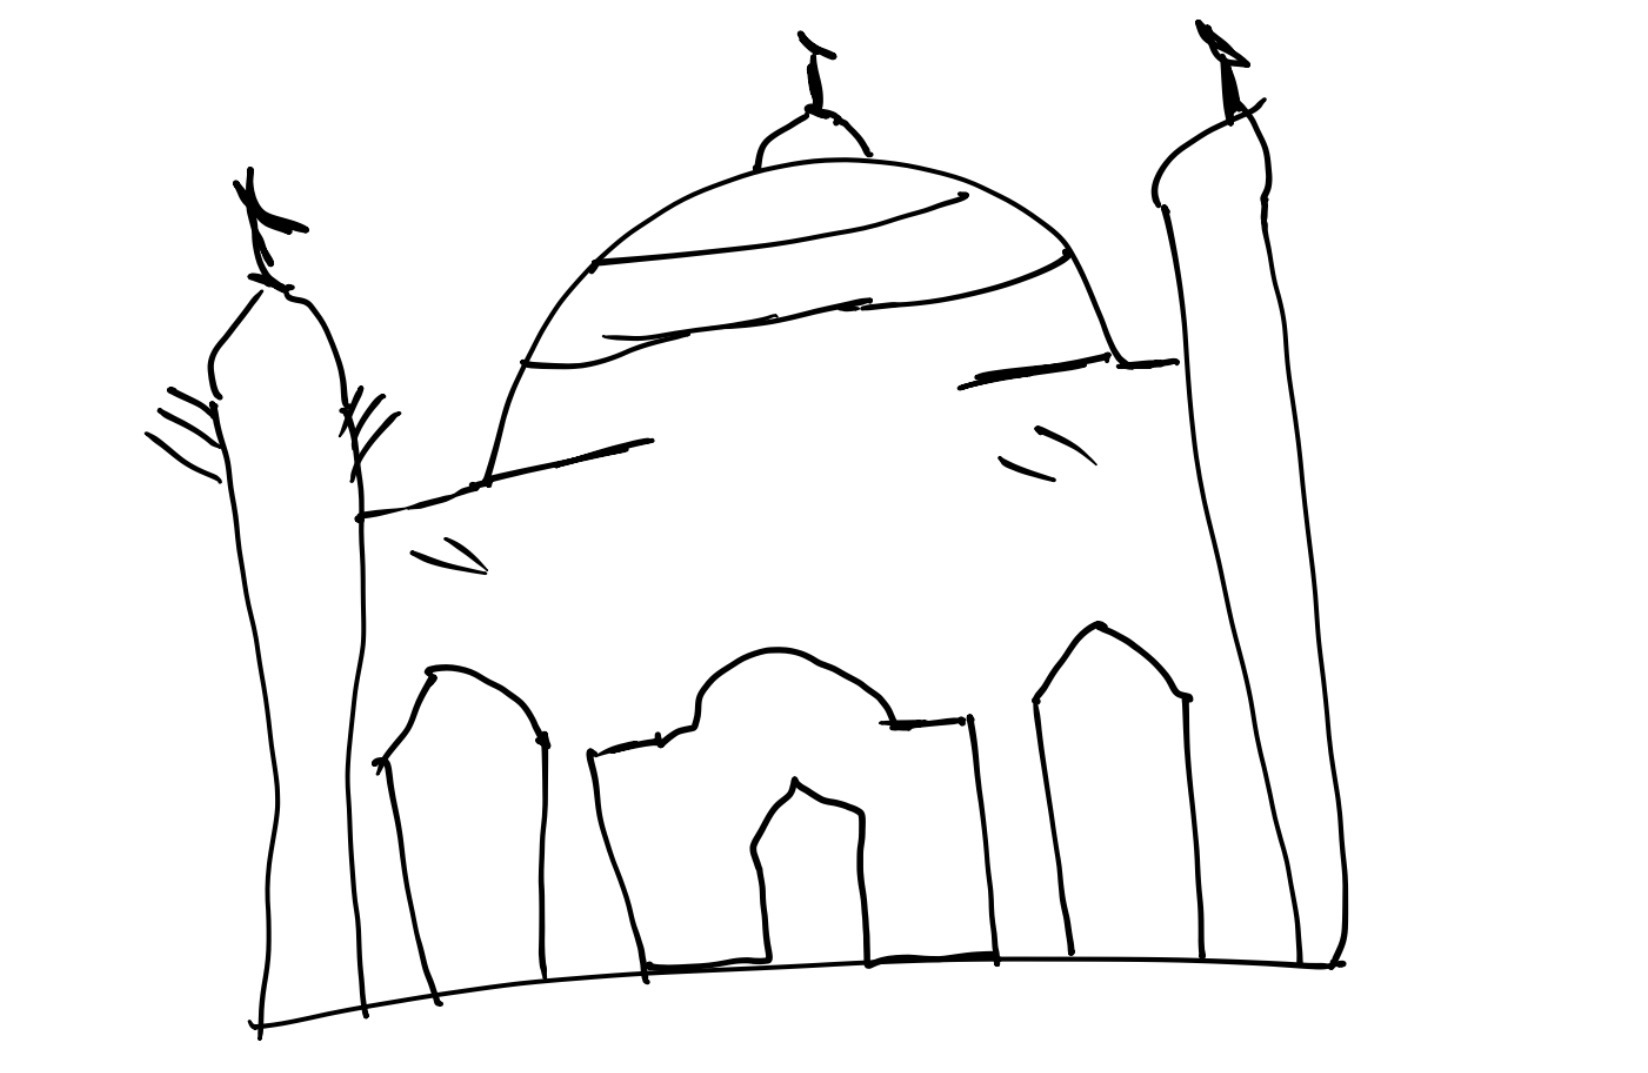

In [5]:
import urllib.request

sketch_path = "mosque.jpg"

display(Image.open(sketch_path))

In [6]:
# Zero-shot classification: what does the sketch depict?
image_input = preprocess(Image.open(sketch_path)).unsqueeze(0).to(device)

text_labels = [
    "a pyramid",
    "a mosque",
    "a temple",
    "a palace",
    "a bridge",
    "a museum",
    "a beach",
    "a stadium",
]
text_tokens = clip.tokenize(text_labels).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_input, text_tokens)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

for label, prob in zip(text_labels, probs[0]):
    print(f"  {label}: {prob:.4f}")


  a pyramid: 0.0003
  a mosque: 0.9761
  a temple: 0.0158
  a palace: 0.0061
  a bridge: 0.0002
  a museum: 0.0007
  a beach: 0.0001
  a stadium: 0.0009


In [7]:
image_paths = glob.glob("dataset/images/*/*.jpg")
print("Number of images found:", len(image_paths))
assert image_paths, "No images found! Check the dataset/images/ path."

image_features_list = []

for path in image_paths:
    img = preprocess(Image.open(path)).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.encode_image(img)
        features /= features.norm(dim=-1, keepdim=True)

    image_features_list.append(features)

image_features = torch.cat(image_features_list)
print("Image feature shape:", image_features.shape)


Number of images found: 5399
Image feature shape: torch.Size([5399, 512])


In [8]:
os.makedirs("embeddings", exist_ok=True)

torch.save(image_features, "embeddings/image_features.pt")

with open("embeddings/image_paths.pkl", "wb") as f:
    pickle.dump(image_paths, f)

print("Embeddings saved.")


Embeddings saved.


=== BEFORE filtering (raw retrieval) ===
  [1] Pyramid_of_Nyuserre_Ini  score=0.7515
  [2] Mosque-Madrassa_of_Sultan_Hassan  score=0.7495
  [3] Al-Salih_Tala'i_Mosque  score=0.7485
  [4] Sulayman_Agha_al-Silahdar_Mosque  score=0.7456
  [5] Bab_al-Nasr_(Cairo)  score=0.7373


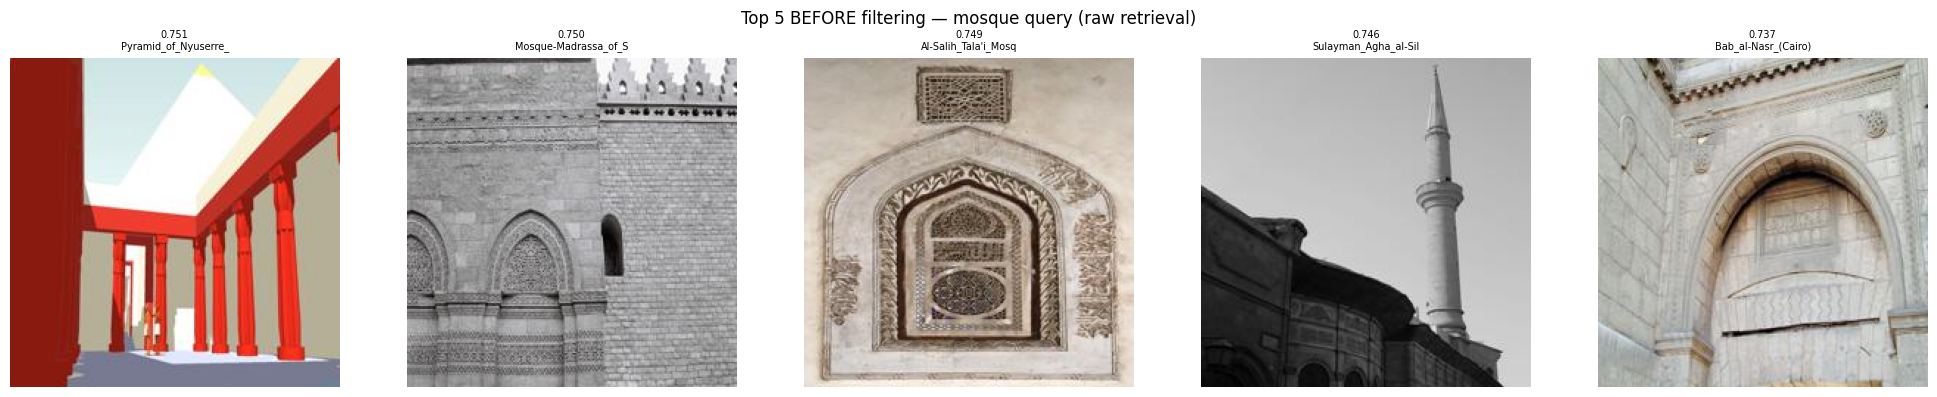


Removed 476 diagram-like images (8.8%)
Clean index: 4923 images
Saved → embeddings/image_features_clean.pt

=== AFTER filtering (clean retrieval) ===
  [1] Mosque-Madrassa_of_Sultan_Hassan  score=0.7495
  [2] Al-Salih_Tala'i_Mosque  score=0.7485
  [3] Sulayman_Agha_al-Silahdar_Mosque  score=0.7456
  [4] Bab_al-Nasr_(Cairo)  score=0.7373
  [5] Madrasah_of_Al-Nasir_Muhammad  score=0.7324


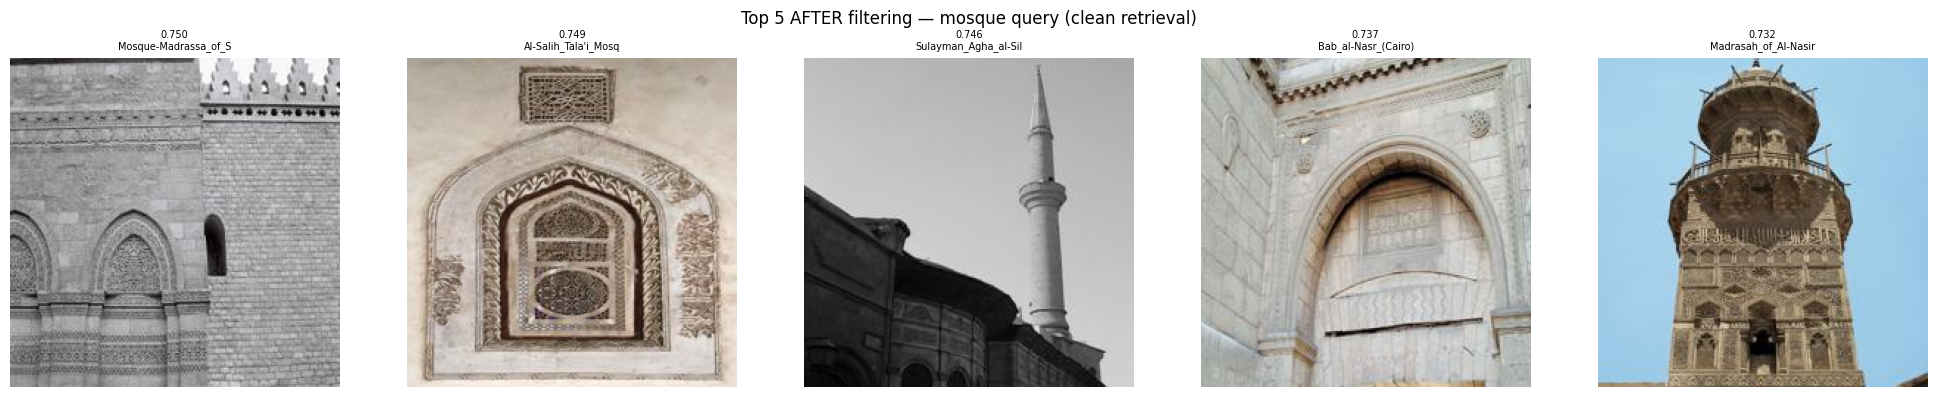

In [9]:
# Load raw embeddings
image_features = torch.load("embeddings/image_features.pt", weights_only=True).to(device)
with open("embeddings/image_paths.pkl", "rb") as f:
    image_paths = pickle.load(f)

# Encode query sketch
sketch = preprocess(Image.open(sketch_path)).unsqueeze(0).to(device)
with torch.no_grad():
    sketch_feat = model.encode_image(sketch)
    sketch_feat /= sketch_feat.norm(dim=-1, keepdim=True)

# --- BEFORE filtering ---
sims_raw = (sketch_feat @ image_features.T).cpu().numpy()
top_k = 5
top_raw = sims_raw.argsort()[0][-top_k:][::-1]

print("=== BEFORE filtering (raw retrieval) ===")
fig, axes = plt.subplots(1, top_k, figsize=(20, 4))
for i, idx in enumerate(top_raw):
    path = image_paths[idx]
    class_name = path.split("/")[-2]
    print(f"  [{i+1}] {class_name}  score={sims_raw[0][idx]:.4f}")
    try:
        axes[i].imshow(mpimg.imread(path))
        axes[i].set_title(f"{sims_raw[0][idx]:.3f}\n{class_name[:20]}", fontsize=7)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")
plt.suptitle("Top 5 BEFORE filtering — mosque query (raw retrieval)", fontsize=12)
plt.tight_layout()
plt.show()

# --- Filter: remove diagrams ---
filter_texts = clip.tokenize([
    "a real photograph of a landmark or building",
    "an architectural diagram, floor plan, or technical drawing",
    "a 3D render or computer generated illustration",
]).to(device)

with torch.no_grad():
    filter_feats = model.encode_text(filter_texts)
    filter_feats /= filter_feats.norm(dim=-1, keepdim=True)
    scores = (image_features @ filter_feats.T)

keep_mask = scores[:, 0] > scores[:, 1:].max(dim=1).values
keep_indices = keep_mask.nonzero(as_tuple=True)[0].tolist()
filtered_features = image_features[keep_mask]
filtered_paths = [image_paths[i] for i in keep_indices]

removed = len(image_paths) - len(filtered_paths)
print(f"\nRemoved {removed} diagram-like images ({removed/len(image_paths)*100:.1f}%)")
print(f"Clean index: {len(filtered_paths)} images")

# Save clean index
torch.save(filtered_features.cpu(), "embeddings/image_features_clean.pt")
with open("embeddings/image_paths_clean.pkl", "wb") as f:
    pickle.dump(filtered_paths, f)
print("Saved → embeddings/image_features_clean.pt")

# --- AFTER filtering ---
sims_clean = (sketch_feat @ filtered_features.T).cpu().numpy()
top_clean = sims_clean.argsort()[0][-top_k:][::-1]

print("\n=== AFTER filtering (clean retrieval) ===")
fig, axes = plt.subplots(1, top_k, figsize=(20, 4))
for i, idx in enumerate(top_clean):
    path = filtered_paths[idx]
    class_name = path.split("/")[-2]
    print(f"  [{i+1}] {class_name}  score={sims_clean[0][idx]:.4f}")
    try:
        axes[i].imshow(mpimg.imread(path))
        axes[i].set_title(f"{sims_clean[0][idx]:.3f}\n{class_name[:20]}", fontsize=7)
        axes[i].axis("off")
    except Exception:
        axes[i].axis("off")
plt.suptitle("Top 5 AFTER filtering — mosque query (clean retrieval)", fontsize=12)
plt.tight_layout()
plt.show()